# 🗑️ Garbage Image Classification - Data Preparation

## Project Overview
โปรเจคนี้เป็นการสร้าง AI Model สำหรับจำแนกรูปภาพขยะ (Garbage Image Classification)
โดยจะใช้โมเดล Machine Learning 3 โมเดล ได้แก่:
1. **KNN** (K-Nearest Neighbors)
2. **SVM** (Support Vector Machine)
3. **CNN** (Convolutional Neural Network)

### Category Mapping
จำแนกขยะ 10 ประเภทย่อย ให้เป็น 4 กลุ่มหลัก:

| ประเภทย่อย | กลุ่มหลัก |
|---|---|
| Battery | Hazardous |
| Biological | Organic |
| Cardboard, Glass, Metal, Paper, Plastic | Recyclable |
| Clothes, Shoes, Trash | Others |

## Data Collection

---
## 1. Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("✅ Import libraries สำเร็จ")

✅ Import libraries สำเร็จ


---
## 2. กำหนด Path และ Category Mapping

In [2]:
DATA_DIR = 'original'

# Mapping จากประเภทย่อย -> กลุ่มหลัก
category_map = {
    'battery': 'Hazardous',
    'biological': 'Organic',
    'cardboard': 'Recyclable',
    'glass': 'Recyclable',
    'metal': 'Recyclable',
    'paper': 'Recyclable',
    'plastic': 'Recyclable',
    'clothes': 'Others',
    'shoes': 'Others',
    'trash': 'Others'
}

IMG_SIZE = 128
print("Category Mapping:")
for sub, main in category_map.items():
    print(f"   {sub:<12} -> {main}")

print(f"\nData Directory: {DATA_DIR}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")

Category Mapping:
   battery      -> Hazardous
   biological   -> Organic
   cardboard    -> Recyclable
   glass        -> Recyclable
   metal        -> Recyclable
   paper        -> Recyclable
   plastic      -> Recyclable
   clothes      -> Others
   shoes        -> Others
   trash        -> Others

Data Directory: original
Image Size: 128x128


---
## 3. สำรวจข้อมูล (Data Exploration)
สำรวจจำนวนรูปภาพในแต่ละประเภท และแสดงสถิติของชุดข้อมูล

In [3]:
# นับจำนวนรูปภาพในแต่ละประเภท
sub_category_counts = {}
main_category_counts = {}

for folder_name in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder_name)
    if os.path.isdir(folder_path):
        # นับจำนวนไฟล์ภาพในโฟลเดอร์
        valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')
        num_images = len([f for f in os.listdir(folder_path) 
                         if f.lower().endswith(valid_extensions)])
        sub_category_counts[folder_name] = num_images
        
        # รวมจำนวนตามกลุ่มหลัก
        main_cat = category_map.get(folder_name.lower(), 'Unknown')
        main_category_counts[main_cat] = main_category_counts.get(main_cat, 0) + num_images

# แสดงสถิติ
print("=" * 50)
print("📊 สถิติจำนวนรูปภาพในแต่ละประเภทย่อย")
print("=" * 50)
total = 0
for cat, count in sorted(sub_category_counts.items()):
    main_cat = category_map.get(cat.lower(), 'Unknown')
    print(f"   {cat:<12} ({main_cat:<12}): {count:>5} รูป")
    total += count
print(f"{'':>27} Total: {total:>5} รูป")

print(f"\n{'=' * 50}")
print("📊 สถิติจำนวนรูปภาพตามกลุ่มหลัก")
print("=" * 50)
for cat, count in sorted(main_category_counts.items()):
    print(f"   {cat:<12}: {count:>5} รูป")
print(f"   {'Total':<12}: {total:>5} รูป")

📊 สถิติจำนวนรูปภาพในแต่ละประเภทย่อย
   battery      (Hazardous   ):   756 รูป
   biological   (Organic     ):   699 รูป
   cardboard    (Recyclable  ):  1411 รูป
   clothes      (Others      ):  1892 รูป
   glass        (Recyclable  ):  1736 รูป
   metal        (Recyclable  ):   930 รูป
   paper        (Recyclable  ):  1336 รูป
   plastic      (Recyclable  ):  1597 รูป
   shoes        (Others      ):  1449 รูป
   trash        (Others      ):   453 รูป
                            Total: 12259 รูป

📊 สถิติจำนวนรูปภาพตามกลุ่มหลัก
   Hazardous   :   756 รูป
   Organic     :   699 รูป
   Others      :  3794 รูป
   Recyclable  :  7010 รูป
   Total       : 12259 รูป


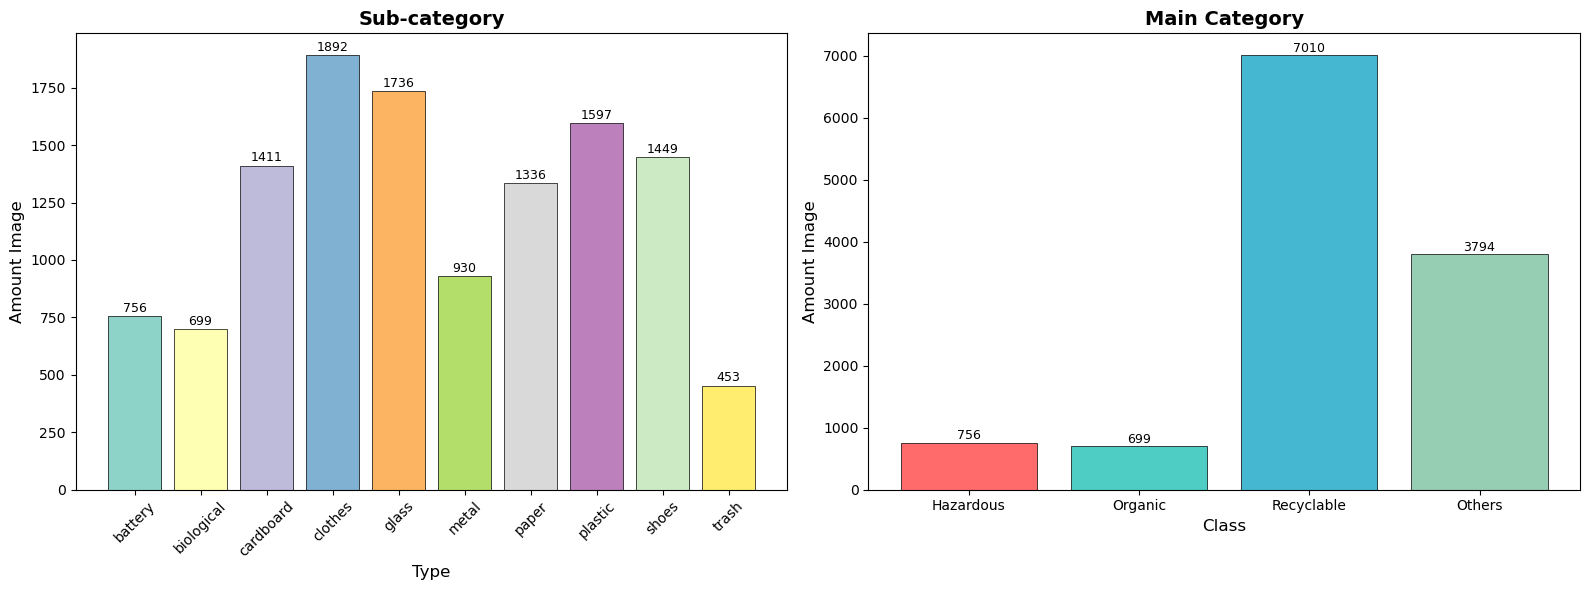

✅ บันทึกกราฟเป็น data_distribution.png


In [4]:
# สร้างกราฟแสดงจำนวนรูปภาพ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# กราฟ 1: จำนวนรูปภาพแต่ละประเภทย่อย
colors_sub = plt.cm.Set3(np.linspace(0, 1, len(sub_category_counts)))
bars1 = axes[0].bar(sub_category_counts.keys(), sub_category_counts.values(), color=colors_sub, edgecolor='black', linewidth=0.5)
axes[0].set_title('Sub-category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Type', fontsize=12)
axes[0].set_ylabel('Amount Image', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

# กราฟ 2: จำนวนรูปภาพแต่ละกลุ่มหลัก
colors_main = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars2 = axes[1].bar(main_category_counts.keys(), main_category_counts.values(), color=colors_main, edgecolor='black', linewidth=0.5)
axes[1].set_title('Main Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Amount Image', fontsize=12)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟเป็น data_distribution.png")

## Data Preprocessing

---
## 4. ตรวจสอบคุณสมบัติของรูปภาพ
ตรวจสอบขนาด, สัดส่วน, และ format ของรูปภาพในชุดข้อมูล

In [5]:
# ตรวจสอบคุณสมบัติของรูปภาพ
img_widths = []
img_heights = []
img_formats = []
img_modes = []

categories = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]

for cat in categories:
    cat_path = os.path.join(DATA_DIR, cat)
    images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'))]
    
    for img_name in images:
        try:
            img_path = os.path.join(cat_path, img_name)
            img = Image.open(img_path)
            w, h = img.size
            img_widths.append(w)
            img_heights.append(h)
            img_formats.append(img.format)
            img_modes.append(img.mode)
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

print("=" * 50)
print("📐 คุณสมบัติของรูปภาพ")
print("=" * 50)
print(f"   จำนวนรูปภาพทั้งหมด: {len(img_widths)}")
print(f"   Width  - Min: {min(img_widths)}, Max: {max(img_widths)}, Mean: {np.mean(img_widths):.0f}")
print(f"   Height - Min: {min(img_heights)}, Max: {max(img_heights)}, Mean: {np.mean(img_heights):.0f}")
print(f"   Formats: {Counter(img_formats)}")
print(f"   Modes  : {Counter(img_modes)}")

📐 คุณสมบัติของรูปภาพ
   จำนวนรูปภาพทั้งหมด: 12259
   Width  - Min: 51, Max: 7786, Mean: 440
   Height - Min: 71, Max: 6283, Mean: 431
   Formats: Counter({'JPEG': 12252, 'MPO': 5, 'WEBP': 2})
   Modes  : Counter({'RGB': 12259})


---
## 5. โหลดและ Preprocess รูปภาพ
โหลดรูปภาพทั้งหมด, Resize ให้เป็นขนาดเดียวกัน, แปลงเป็น array และ normalize

In [6]:
def load_and_preprocess_images(data_dir, category_map, img_size=128):
    images = []
    sub_labels = []
    main_labels = []
    error_count = 0
    
    categories = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    
    for cat in categories:
        cat_path = os.path.join(data_dir, cat)
        img_files = [f for f in os.listdir(cat_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'))]
        
        print(f"Loading {cat:<12} ... ", end='')
        count = 0
        
        for img_name in img_files:
            try:
                img_path = os.path.join(cat_path, img_name)
                # อ่านรูปภาพด้วย OpenCV
                img = cv2.imread(img_path)
                if img is None:
                    error_count += 1
                    continue
                
                # แปลง BGR -> RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Resize
                img = cv2.resize(img, (img_size, img_size))
                
                images.append(img)
                sub_labels.append(cat)
                main_labels.append(category_map.get(cat.lower(), 'Unknown'))
                count += 1
                
            except Exception as e:
                error_count += 1
        
        print(f"{count} รูป")
    
    images = np.array(images)
    
    print(f"\n✅ โหลดรูปภาพเสร็จสิ้น")
    print(f"   จำนวนรูปภาพที่โหลดได้: {len(images)}")
    print(f"   จำนวนรูปภาพที่ error: {error_count}")
    print(f"   Shape: {images.shape}")
    
    return images, sub_labels, main_labels

# โหลดรูปภาพ
print("กำลังโหลดและ preprocess รูปภาพ...\n")
images, sub_labels, main_labels = load_and_preprocess_images(DATA_DIR, category_map, IMG_SIZE)

กำลังโหลดและ preprocess รูปภาพ...

Loading battery      ... 756 รูป
Loading biological   ... 699 รูป
Loading cardboard    ... 1411 รูป
Loading clothes      ... 1892 รูป
Loading glass        ... 1736 รูป
Loading metal        ... 930 รูป
Loading paper        ... 1336 รูป
Loading plastic      ... 1597 รูป
Loading shoes        ... 1449 รูป
Loading trash        ... 453 รูป

✅ โหลดรูปภาพเสร็จสิ้น
   จำนวนรูปภาพที่โหลดได้: 12259
   จำนวนรูปภาพที่ error: 0
   Shape: (12259, 128, 128, 3)


---
## 6. Encode Labels
แปลง label จาก text เป็นตัวเลขด้วย LabelEncoder

In [7]:
# Encode labels สำหรับกลุ่มหลัก (Main Category)
label_encoder = LabelEncoder()
main_labels_encoded = label_encoder.fit_transform(main_labels)

print("📋 Label Encoding (Main Category):")
for i, cls in enumerate(label_encoder.classes_):
    count = np.sum(main_labels_encoded == i)
    print(f"   {cls:<12} -> {i}  ({count} รูป)")

print(f"\n   จำนวน classes: {len(label_encoder.classes_)}")
print(f"   Encoded labels shape: {main_labels_encoded.shape}")

📋 Label Encoding (Main Category):
   Hazardous    -> 0  (756 รูป)
   Organic      -> 1  (699 รูป)
   Others       -> 2  (3794 รูป)
   Recyclable   -> 3  (7010 รูป)

   จำนวน classes: 4
   Encoded labels shape: (12259,)


## Feature Engineering

---
## 7. Normalize ข้อมูล
ทำ Normalization โดยแปลงค่า pixel จาก [0, 255] เป็น [0, 1]

In [8]:
# Normalize pixel values
images_normalized = images.astype('float32') / 255.0

print(f"📊 ก่อน Normalize:")
print(f"   Min pixel: {images.min()}, Max pixel: {images.max()}, dtype: {images.dtype}")
print(f"\n📊 หลัง Normalize:")
print(f"   Min pixel: {images_normalized.min():.4f}, Max pixel: {images_normalized.max():.4f}, dtype: {images_normalized.dtype}")
print(f"   Shape: {images_normalized.shape}")

📊 ก่อน Normalize:
   Min pixel: 0, Max pixel: 255, dtype: uint8

📊 หลัง Normalize:
   Min pixel: 0.0000, Max pixel: 1.0000, dtype: float32
   Shape: (12259, 128, 128, 3)


---
##  Train/Test Split (80/20)
แบ่งข้อมูลเป็น training set (80%) และ test set (20%) โดยใช้ `stratify` เพื่อรักษาสัดส่วน class


In [ ]:
TEST_SIZE = 0.3
RANDOM_STATE = 42

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    images_normalized, main_labels_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=main_labels_encoded  # รักษาสัดส่วนของแต่ละ class
)

print("=" * 50)
print("✂️ ผลการแบ่ง Train/Test Split")
print("=" * 50)
print(f"   X_train shape : {X_train.shape}")
print(f"   X_test shape  : {X_test.shape}")
print(f"   y_train shape : {y_train.shape}")
print(f"   y_test shape  : {y_test.shape}")

# แสดงการกระจายใน train/test
print(f"\n📊 การกระจายใน Training Set:")
train_counter = Counter(y_train)
for label_id in sorted(train_counter.keys()):
    label_name = label_encoder.inverse_transform([label_id])[0]
    count = train_counter[label_id]
    pct = count / len(y_train) * 100
    print(f"   {label_name:<12}: {count:>5} ({pct:.1f}%)")
print(f"   {'Total':<12}: {len(y_train):>5}")

print(f"\n📊 การกระจายใน Test Set:")
test_counter = Counter(y_test)
for label_id in sorted(test_counter.keys()):
    label_name = label_encoder.inverse_transform([label_id])[0]
    count = test_counter[label_id]
    pct = count / len(y_test) * 100
    print(f"   {label_name:<12}: {count:>5} ({pct:.1f}%)")
print(f"   {'Total':<12}: {len(y_test):>5}")


✂️ ผลการแบ่ง Train/Test Split
   X_train shape : (9807, 128, 128, 3)
   X_test shape  : (2452, 128, 128, 3)
   y_train shape : (9807,)
   y_test shape  : (2452,)

📊 การกระจายใน Training Set:
   Hazardous   :   605 (6.2%)
   Organic     :   559 (5.7%)
   Others      :  3035 (30.9%)
   Recyclable  :  5608 (57.2%)
   Total       :  9807

📊 การกระจายใน Test Set:
   Hazardous   :   151 (6.2%)
   Organic     :   140 (5.7%)
   Others      :   759 (31.0%)
   Recyclable  :  1402 (57.2%)
   Total       :  2452


## KNN Modle

In [12]:
from sklearn.decomposition import PCA

X_train_flat = X_train.reshape(X_train.shape[0], -1)  
X_test_flat = X_test.reshape(X_test.shape[0], -1)     

pca = PCA(n_components=500) 
X_train_pca = pca.fit_transform(X_train_flat)  
X_test_pca = pca.transform(X_test_flat)       

print(f"Flatten shape: {X_train_flat.shape}")
print(f"PCA shape: {X_train_pca.shape}")
print(f"Explained variance: {sum(pca.explained_variance_ratio_):.2%}")


Flatten shape: (9807, 49152)
PCA shape: (9807, 500)
Explained variance: 92.49%


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn,
      target_names=['Hazardous','Organic','Others','Recyclable']))


KNN Accuracy: 0.7239
              precision    recall  f1-score   support

   Hazardous       0.66      0.43      0.52       151
     Organic       0.38      0.09      0.15       140
      Others       0.68      0.68      0.68       759
  Recyclable       0.76      0.84      0.80      1402

    accuracy                           0.72      2452
   macro avg       0.62      0.51      0.54      2452
weighted avg       0.71      0.72      0.71      2452



##  กราฟ ACC ของ Train,Test

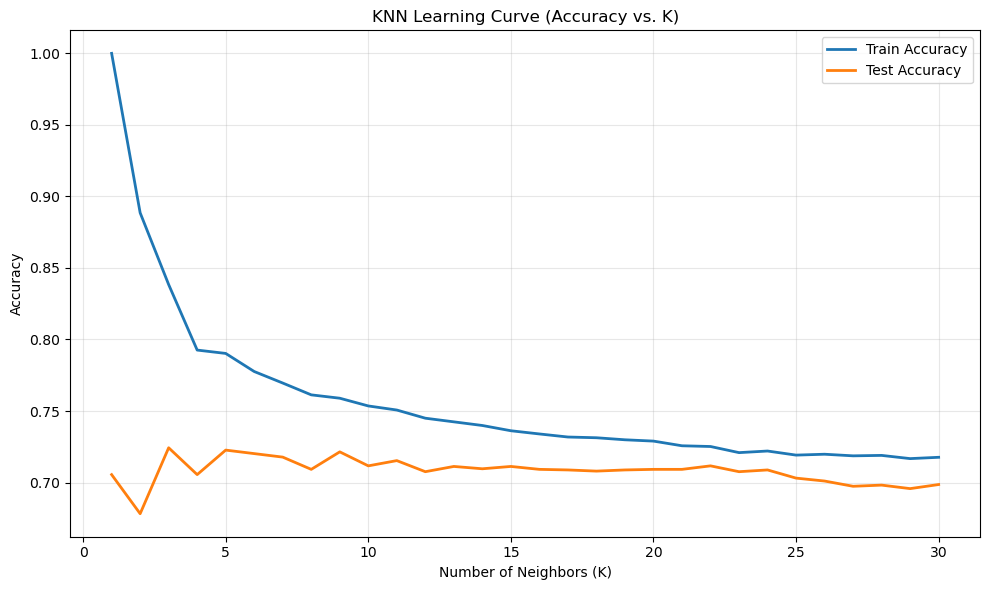

✅ Best K = 3, Test Accuracy = 0.7243


In [ ]:
k_range = range(1, 31)
train_accs = []
test_accs = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_pca, y_train)
    train_accs.append(accuracy_score(y_train, knn_temp.predict(X_train_pca)))
    test_accs.append(accuracy_score(y_test, knn_temp.predict(X_test_pca)))

plt.figure(figsize=(10, 6))
plt.plot(k_range, train_accs, label='Train Accuracy', linewidth=2)
plt.plot(k_range, test_accs, label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Learning Curve (Accuracy vs. K)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_learning_curve.png', dpi=150)
plt.show()

best_k = list(k_range)[test_accs.index(max(test_accs))]
print(f"✅ Best K = {best_k}, Test Accuracy = {max(test_accs):.4f}")


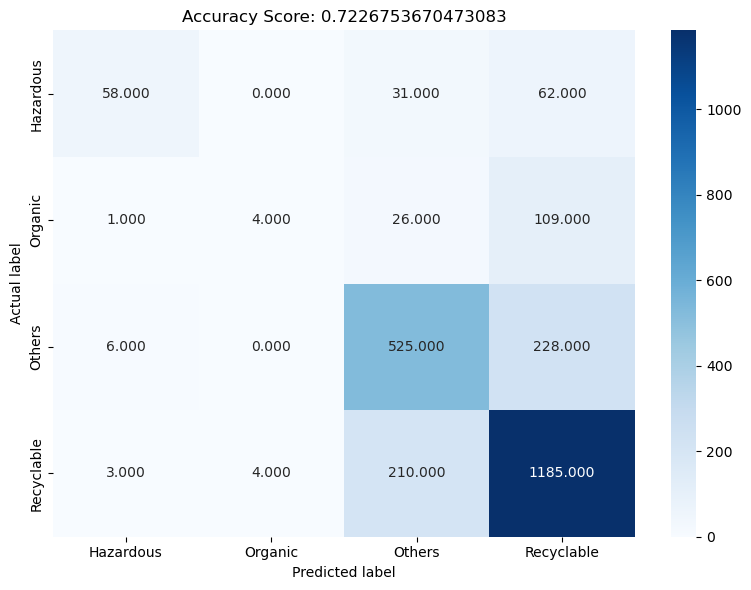

In [ ]:
from sklearn.metrics import confusion_matrix

# สร้าง Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
acc = accuracy_score(y_test, y_pred_knn)

labels = ['Hazardous', 'Organic', 'Others', 'Recyclable']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'Accuracy Score: {acc}')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150)
plt.show()


## 2.SVM

# 1. Import and Train SVM Model

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
import time

# SVM with RBF kernel
print("\n  Training SVM (kernel='rbf', C=10, gamma='scale')...")
start_time = time.time()

svm_model = SVC(
    kernel='rbf',
    C=4,
    gamma='scale',
    decision_function_shape='ovr',
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_pca, y_train)

train_time = time.time() - start_time
print(f"  ✅ SVM Training completed in {train_time:.2f} seconds")


  Training SVM (kernel='rbf', C=10, gamma='scale')...
  ✅ SVM Training completed in 35.99 seconds


# 2.Evaluate SVM Model

In [20]:
# Predict
y_pred_train = svm_model.predict(X_train_pca)
y_pred_test = svm_model.predict(X_test_pca)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n  Training Accuracy : {train_acc:.4f}")
print(f"  Test Accuracy     : {test_acc:.4f}")

LABELS = ['Hazardous', 'Organic', 'Others', 'Recyclable']
# Classification Report
print(f"\n  📋 Classification Report (Test Set):")
print(classification_report(
    y_test, y_pred_test,
    target_names=LABELS,
    digits=4
))


  Training Accuracy : 0.9545
  Test Accuracy     : 0.7741

  📋 Classification Report (Test Set):
              precision    recall  f1-score   support

   Hazardous     0.8144    0.5232    0.6371       151
     Organic     0.6216    0.3286    0.4299       140
      Others     0.7756    0.6785    0.7238       759
  Recyclable     0.7780    0.8973    0.8334      1402

    accuracy                         0.7741      2452
   macro avg     0.7474    0.6069    0.6561      2452
weighted avg     0.7706    0.7741    0.7643      2452



# 3. SVM Learning Curve

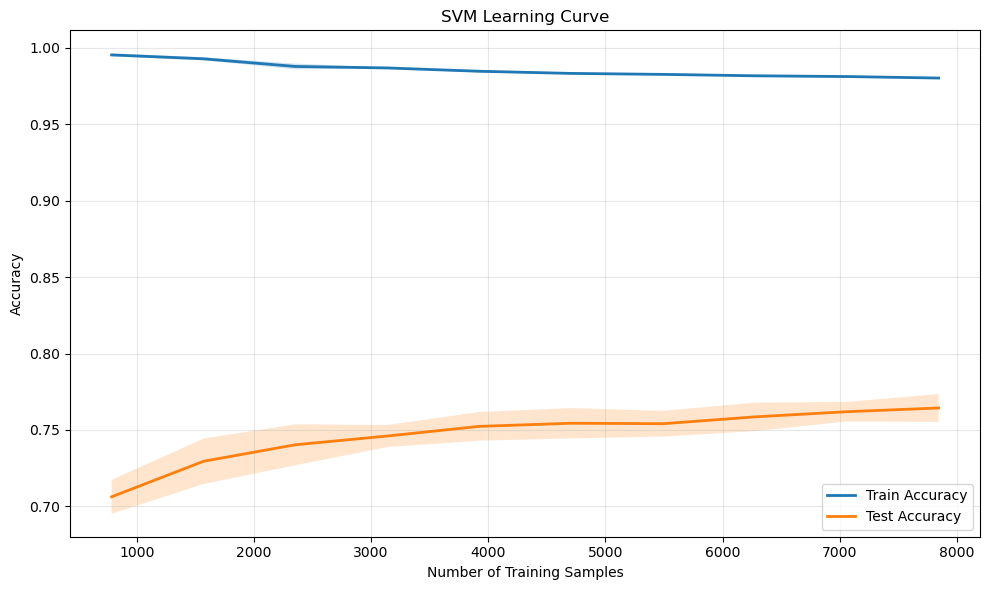

Best Test Accuracy = 0.7644


In [17]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# คำนวณ Learning Curve สำหรับ SVM
train_sizes, train_scores, test_scores = learning_curve(
    svm_model,
    X_train_pca,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Train Accuracy", linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, test_mean,  label="Test Accuracy",  linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std,  test_mean + test_std,  alpha=0.2)
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("SVM Learning Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("svm_learning_curve.png", dpi=150)
plt.show()
print(f"Best Test Accuracy = {test_mean[-1]:.4f}")

# 3. Confusion Matrix

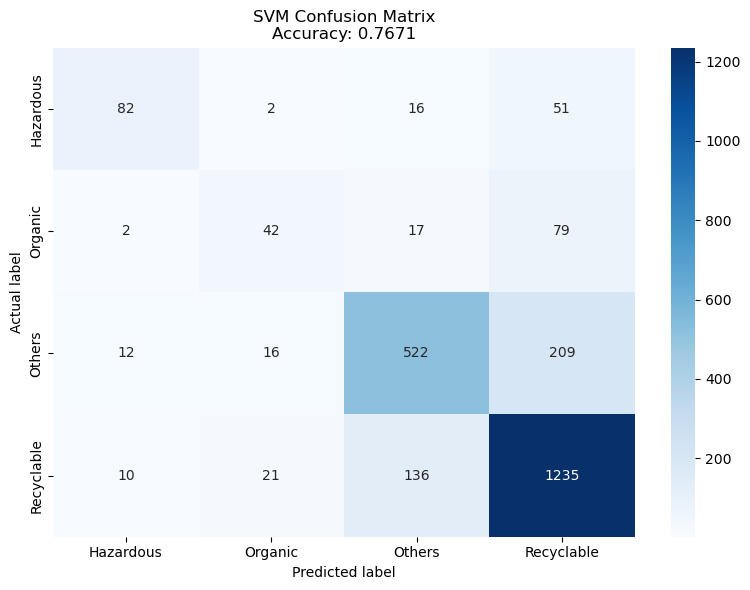

  ✅ Saved: svm_confusion_matrix.png


In [18]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'SVM Confusion Matrix\nAccuracy: {test_acc:.4f}')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()
print("  ✅ Saved: svm_confusion_matrix.png")

# 4. Normalized Confusion Matrix

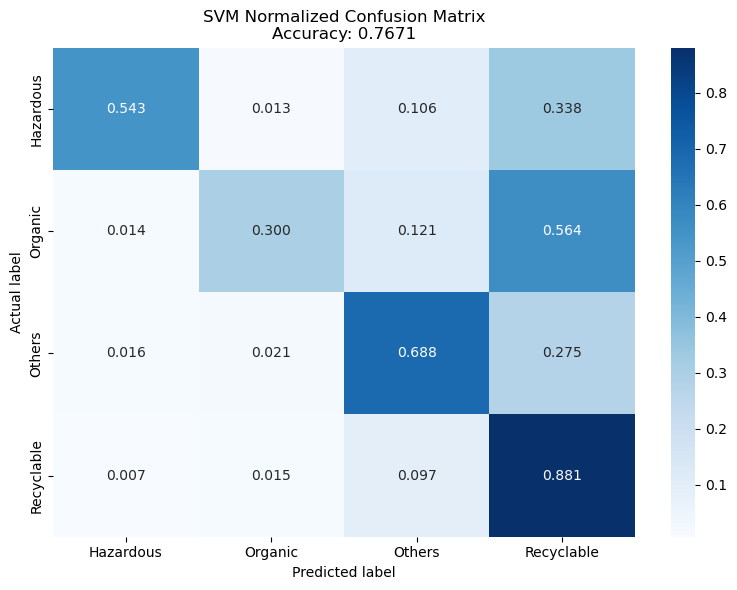

  ✅ Saved: svm_confusion_matrix_normalized.png


In [19]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'SVM Normalized Confusion Matrix\nAccuracy: {test_acc:.4f}')
plt.tight_layout()
plt.savefig('svm_confusion_matrix_normalized.png', dpi=150)
plt.show()
print("  ✅ Saved: svm_confusion_matrix_normalized.png")



# 3. CNN (Convolutional Neural Network)

In [23]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

print("✅ TensorFlow version:", tf.__version__)
print("✅ Keras imported successfully")

✅ TensorFlow version: 2.21.0
✅ Keras imported successfully


## 1. Data Preparation for CNN

In [24]:
# Prepare data for CNN
# Add channel dimension if needed (grayscale images)
if len(X_train.shape) == 3:
    X_train_cnn = np.expand_dims(X_train, axis=-1)  # (N, 128, 128) -> (N, 128, 128, 1)
    X_test_cnn = np.expand_dims(X_test, axis=-1)
else:
    X_train_cnn = tf.image.rgb_to_grayscale(X_train)
    X_test_cnn = tf.image.rgb_to_grayscale(X_test)

# Convert labels to one-hot encoding for CNN
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

print("=" * 50)
print("📊 CNN Data Shapes")
print("=" * 50)
print(f"  X_train_cnn shape  : {X_train_cnn.shape}")
print(f"  X_test_cnn shape   : {X_test_cnn.shape}")
print(f"  y_train_cat shape  : {y_train_cat.shape}")
print(f"  y_test_cat shape   : {y_test_cat.shape}")
print(f"  Input image size   : {X_train_cnn.shape[1:3]}")
print(f"  Number of classes  : {y_train_cat.shape[1]}")

📊 CNN Data Shapes
  X_train_cnn shape  : (9807, 128, 128, 1)
  X_test_cnn shape   : (2452, 128, 128, 1)
  y_train_cat shape  : (9807, 4)
  y_test_cat shape   : (2452, 4)
  Input image size   : (128, 128)
  Number of classes  : 4


## 2. Build CNN Architecture

In [25]:
# Build CNN Model
def create_cnn_model(input_shape=(128, 128, 1), num_classes=4):
    """
    Create a Convolutional Neural Network for image classification
    
    Architecture:
    - Conv Block 1: Conv(32) -> Conv(32) -> MaxPool
    - Conv Block 2: Conv(64) -> Conv(64) -> MaxPool
    - Conv Block 3: Conv(128) -> Conv(128) -> MaxPool
    - Flatten + Dense(256) + Dropout(0.5) + Dense(4) + Softmax
    """
    model = models.Sequential([
        # Block 1: 64 -> 32 -> 16
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2: 16 -> 8
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3: 8 -> 4
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the CNN model
model_cnn = create_cnn_model(input_shape=(128, 128, 1), num_classes=4)

# Display model summary
print("=" * 70)
print("🧠 CNN Model Architecture")
print("=" * 70)
model_cnn.summary()

🧠 CNN Model Architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,712,036 (33.23 MB)

 Trainable params: 8,710,372 (33.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

## 3. Compile CNN Model

In [26]:
# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss_fn = keras.losses.CategoricalCrossentropy()
metrics = ['accuracy']

model_cnn.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=metrics
)

print("=" * 70)
print("✅ Model Compiled Successfully")
print("=" * 70)
print(f"  Optimizer     : Adam (lr=0.001)")
print(f"  Loss Function : Categorical Crossentropy")
print(f"  Metrics       : Accuracy")

✅ Model Compiled Successfully
  Optimizer     : Adam (lr=0.001)
  Loss Function : Categorical Crossentropy
  Metrics       : Accuracy


## 4. Train CNN Model

In [27]:
# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train the model
print("=" * 70)
print("🚀 Training CNN Model...")
print("=" * 70)

start_training = time.time()

history = model_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

training_time = time.time() - start_training
print(f"\n✅ Training completed in {training_time:.2f} seconds")
print(f"   Total epochs trained: {len(history.history['loss'])}")

🚀 Training CNN Model...
Epoch 1/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.5115 - loss: 1.3488 - val_accuracy: 0.3563 - val_loss: 1.2395 - learning_rate: 0.0010
Epoch 2/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.6500 - loss: 0.9132 - val_accuracy: 0.6498 - val_loss: 0.8817 - learning_rate: 0.0010
Epoch 3/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.6897 - loss: 0.7889 - val_accuracy: 0.5306 - val_loss: 1.0606 - learning_rate: 0.0010
Epoch 4/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.7250 - loss: 0.6950 - val_accuracy: 0.1193 - val_loss: 3.8798 - learning_rate: 0.0010
Epoch 5/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.7431 - loss: 0.6447 - val_accuracy: 0.7217 - val_loss: 0.6753 - learning_rate: 0.0010
Epoch 6/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.7639 - loss: 0.6120 - val_accuracy: 0.5392 - val_loss: 1.0670 - learning_rate: 0.0010
Epoch 7/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - acc

## 5. Evaluate CNN Model

In [28]:
# Evaluate on test set
print("=" * 70)
print("📊 Model Evaluation on Test Set")
print("=" * 70)

test_loss, test_accuracy = model_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy:.4f}")

# Make predictions
y_pred_cnn_prob = model_cnn.predict(X_test_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)

# Classification report
LABELS = ['Hazardous', 'Organic', 'Others', 'Recyclable']
print(f"\n📋 Classification Report (Test Set):")
print(classification_report(y_test, y_pred_cnn, target_names=LABELS, digits=4))

📊 Model Evaluation on Test Set
  Test Loss     : 0.5705
  Test Accuracy : 0.7867

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

   Hazardous     0.6797    0.5762    0.6237       151
     Organic     0.5260    0.6500    0.5815       140
      Others     0.7626    0.7194    0.7403       759
  Recyclable     0.8397    0.8595    0.8495      1402

    accuracy                         0.7867      2452
   macro avg     0.7020    0.7013    0.6987      2452
weighted avg     0.7881    0.7867    0.7865      2452



## 6. Training History Visualization

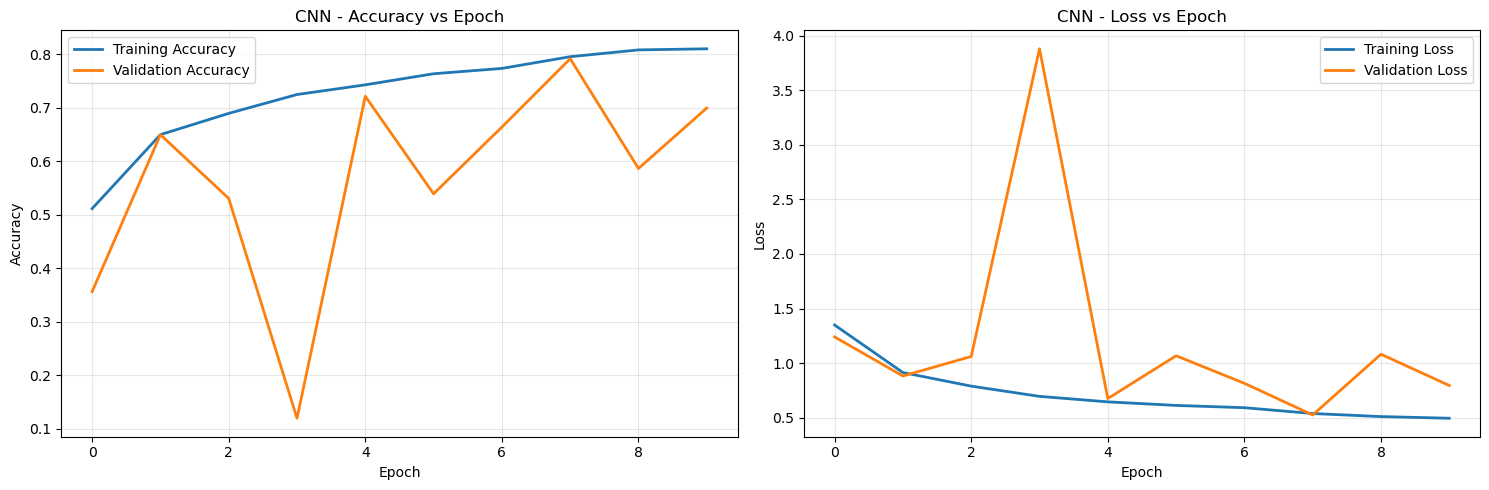

✅ Saved: cnn_training_history.png


In [29]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN - Accuracy vs Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('CNN - Loss vs Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150)
plt.show()
print("✅ Saved: cnn_training_history.png")

## 7. Confusion Matrix

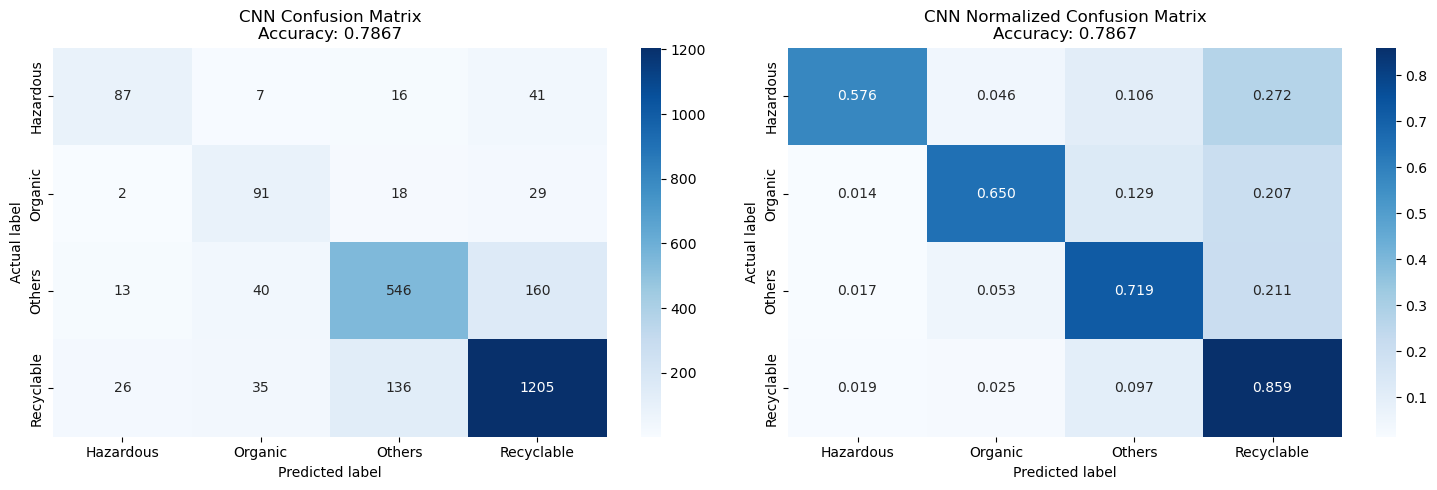

✅ Saved: cnn_confusion_matrix.png


In [30]:
# Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-normalized confusion matrix
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')
axes[0].set_title(f'CNN Confusion Matrix\nAccuracy: {test_accuracy:.4f}')

# Normalized confusion matrix
cm_normalized = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[1])
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('Actual label')
axes[1].set_title(f'CNN Normalized Confusion Matrix\nAccuracy: {test_accuracy:.4f}')

plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved: cnn_confusion_matrix.png")

## 8. Model Comparison Summary

🏆 MODEL COMPARISON SUMMARY
Model  Test Accuracy                                 Architecture
  KNN       0.722675               K-Nearest Neighbors (k=5, PCA)
  SVM       0.767129          Support Vector Machine (RBF kernel)
  CNN       0.786705 Convolutional Neural Network (3 Conv Blocks)


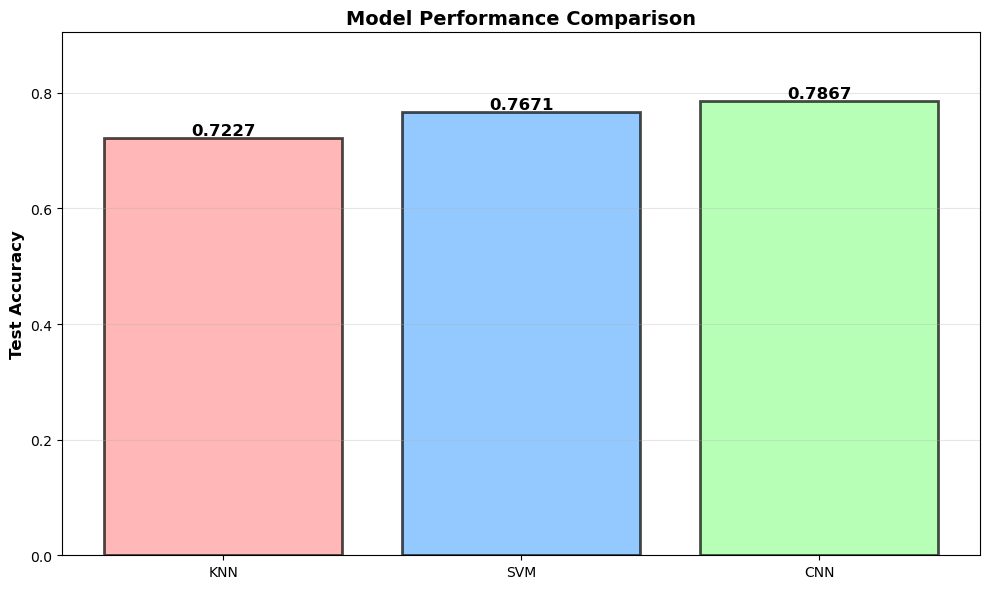

✅ Saved: model_comparison.png


In [31]:
# Retrieve accuracies from previous models
knn_accuracy = accuracy_score(y_test, y_pred_knn)
svm_accuracy = accuracy_score(y_test, y_pred_test)  # SVM predictions
cnn_accuracy = test_accuracy

# Create comparison dataframe
comparison_data = {
    'Model': ['KNN', 'SVM', 'CNN'],
    'Test Accuracy': [knn_accuracy, svm_accuracy, cnn_accuracy],
    'Architecture': [
        'K-Nearest Neighbors (k=5, PCA)',
        'Support Vector Machine (RBF kernel)',
        'Convolutional Neural Network (3 Conv Blocks)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("🏆 MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
models = comparison_df['Model'].values
accuracies = comparison_df['Test Accuracy'].values
colors = ['#FF9999', '#66B2FF', '#99FF99']

bars = ax.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(accuracies) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison.png")

# 📊 Model Comparison: Precision, Recall & F1-Score

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

LABELS = ['Hazardous', 'Organic', 'Others', 'Recyclable']
MODELS = ['KNN', 'SVM', 'CNN']

# คำนวณ Precision, Recall, F1 สำหรับแต่ละโมเดล (weighted avg)
knn_p, knn_r, knn_f, _ = precision_recall_fscore_support(y_test, y_pred_knn, average='weighted')
svm_p, svm_r, svm_f, _ = precision_recall_fscore_support(y_test, y_pred_test, average='weighted')
cnn_p, cnn_r, cnn_f, _ = precision_recall_fscore_support(y_test, y_pred_cnn, average='weighted')

precisions = [knn_p, svm_p, cnn_p]
recalls    = [knn_r, svm_r, cnn_r]
f1_scores  = [knn_f, svm_f, cnn_f]

# Print Summary Table
print('=' * 55)
print('  Model Comparison (Weighted Average)')
print('=' * 55)
print(f'  {"Model":<8} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('-' * 55)
for model, p, r, f in zip(MODELS, precisions, recalls, f1_scores):
    print(f'  {model:<8} {p:>10.4f} {r:>10.4f} {f:>10.4f}')
print('=' * 55)

# Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model Comparison: Precision, Recall & F1-Score\n(Weighted Average)',
             fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('Precision', precisions, '#4C72B0'),
    ('Recall',    recalls,    '#DD8452'),
    ('F1-Score',  f1_scores,  '#55A868'),
]

for ax, (metric_name, values, color) in zip(axes, metrics):
    bars = ax.bar(MODELS, values, color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_title(metric_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xlabel('Model', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, alpha=0.4, linestyle='--')
    ax.set_axisbelow(True)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model_comparison_metrics.png')